In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
np.random.seed(42)

X = np.array([1,2,3,4,5,6,7,8,9], dtype = float)

y = 3 * X + 7 + np.random.normal(0, 1.5, len(X))

print("Dữ liệu:")
for xi, yi in zip(X, y):
    print(f"{xi:.0f} năm KN => {yi:.1f} triệu")

Dữ liệu:
1 năm KN => 10.7 triệu
2 năm KN => 12.8 triệu
3 năm KN => 17.0 triệu
4 năm KN => 21.3 triệu
5 năm KN => 21.6 triệu
6 năm KN => 24.6 triệu
7 năm KN => 30.4 triệu
8 năm KN => 32.2 triệu
9 năm KN => 33.3 triệu


In [8]:
X_mean = X.mean()
Y_mean = y.mean()

numerator = np.sum((X - X_mean) * (y - Y_mean))
denominator = np.sum((X - X_mean) ** 2)

w = numerator / denominator
b =  Y_mean - w * X_mean

print(f"\nModel học được:")
print(f"  w (hệ số góc) ={w:.4f}")
print(f"  b (hệ số chặn) ={b:.4f}")
print(f"  → Phương trình: ŷ ={w:.2f}x +{b:.2f}")





Model học được:
  w (hệ số góc) =2.9740
  b (hệ số chặn) =7.7866
  → Phương trình: ŷ =2.97x +7.79


In [10]:
y_pred = w * X + b

mse = np.mean((y_pred - y) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot =  np.sum((y - Y_mean) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"\nĐánh giá model:")
print(f"  MSE ={mse:.4f}")
print(f"  R²  ={r2:.4f} ({r2*100:.1f}% variance explained)")


Đánh giá model:
  MSE =1.1692
  R²  =0.9806 (98.1% variance explained)


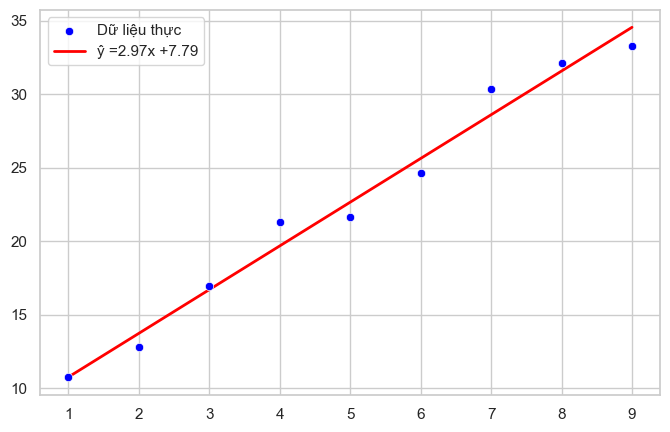

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=X, y=y, color='blue', label='Dữ liệu thực', zorder=5)
sns.lineplot(x=X, y=y_pred, color='red', linewidth=2, label=f'ŷ ={w:.2f}x +{b:.2f}')

plt.legend()
plt.show()

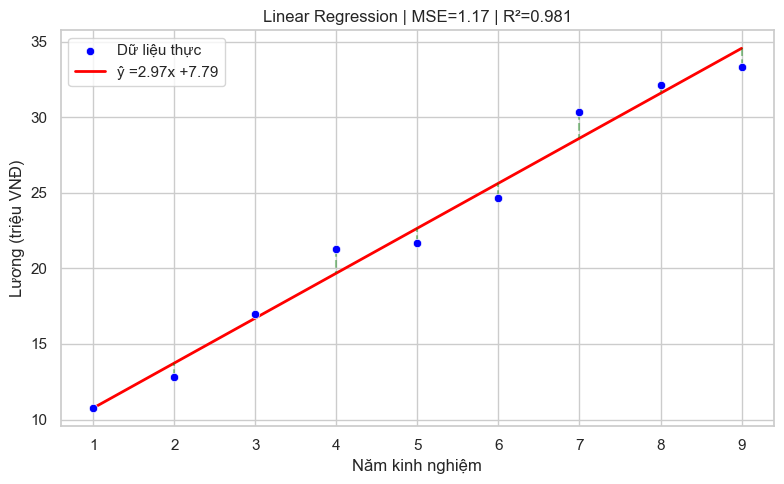

In [17]:
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(8, 5))

sns.scatterplot(x=X, y=y, color='blue', label='Dữ liệu thực', zorder=5)

sns.lineplot(x=X, y=y_pred, color='red', linewidth=2, label=f'ŷ ={w:.2f}x +{b:.2f}')

for xi, yi, ypi in zip(X, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], color='green', linestyle='--', alpha=0.4)

plt.xlabel("Năm kinh nghiệm")
plt.ylabel("Lương (triệu VNĐ)")
plt.title(f"Linear Regression | MSE={mse:.2f} | R²={r2:.3f}")
plt.legend()

plt.tight_layout()

plt.savefig("bai_tap_2_linear_regression_sns.png", dpi=150)
plt.show()

In [19]:
nam_kn_moi = 7
luong_du_doan = w * nam_kn_moi + b
print(f"\nDự đoán:{nam_kn_moi} năm KN →{luong_du_doan:.1f} triệu VNĐ")


Dự đoán:7 năm KN →28.6 triệu VNĐ


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [7]:
print("=" * 60)
print("BƯỚC 1: LOAD DỮ LIỆU")
print("=" * 60)

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name = "MedHouseVal" )

print(f"Shape: {X.shape}")
print(f"\nCác feature:")
for col in X:
    print(f" - {col}")
    
print(f"\nTarget (giá nhà trung bình, đơn vị $100k):")
print(f"  Min: ${y.min():.2f}k  |  Max: ${y.max():.2f}k  |  Mean: ${y.mean():.2f}k")

print(f"\nThống kê cơ bản:")
print(X.describe().round(2))

BƯỚC 1: LOAD DỮ LIỆU
Shape: (20640, 8)

Các feature:
 - MedInc
 - HouseAge
 - AveRooms
 - AveBedrms
 - Population
 - AveOccup
 - Latitude
 - Longitude

Target (giá nhà trung bình, đơn vị $100k):
  Min: $0.15k  |  Max: $5.00k  |  Mean: $2.07k

Thống kê cơ bản:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  
count  20640.00   20640.00  
mean      35.63    -119.57  
std 

In [12]:
print("\n" + "=" * 60)
print("BƯỚC 2: TÁCH TRAIN/TEST")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state= 42
)

print(f"Training set: {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100}%)")
print(f"Test set: {X_test.shape[0]} mẫu ({X_test.shape[0]/ len(X) * 100}%)")


BƯỚC 2: TÁCH TRAIN/TEST
Training set: 16512 mẫu (80.0%)
Test set: 4128 mẫu (20.0%)


In [ ]:
print("\n" + "=" * 60)
print("BƯỚC 3: CHUẨN HOÁ (StandardScaler)")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("Trước chuẩn hóa")
print(f"Mean: {X_train['MedInc'].mean():.2f} | Std: {X_train['MedInc'].std():.2f} ")
print("Sau chuẩn hóa")
print(f"Mean: {X_train_scaled[:, 0].mean():.4f} | Std: {X_train_scaled[:, 0].std():.4f}")




BƯỚC 3: CHUẨN HOÁ (StandardScaler)
Trước chuẩn hóa
Mean: 3.88 | Std: 1.90 
<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
Sau chuẩn hóa
Mean: -0.0000 | Std: 1.0000


In [34]:
print("\n" + "=" * 60)
print("BƯỚC 4: TRAIN MODEL")
print("=" * 60)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model đã được train!")
print(f"\nHệ số (weights) cho từng feature:")
for name, coef in zip(housing.feature_names, model.coef_):
    print(f"{name:12s}:{coef:+.4f}")
print(f"\n  Bias (intercept):{model.intercept_:.4f}")


BƯỚC 4: TRAIN MODEL
Model đã được train!

Hệ số (weights) cho từng feature:
MedInc      :+0.8544
HouseAge    :+0.1225
AveRooms    :-0.2944
AveBedrms   :+0.3393
Population  :-0.0023
AveOccup    :-0.0408
Latitude    :-0.8969
Longitude   :-0.8698

  Bias (intercept):2.0719


In [40]:
print("\n" + "=" * 60)
print("BƯỚC 5: ĐÁNH GIÁ MODEL")
print("=" * 60)

y_pred = model.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

y_train_pred = model.predict(X_train_scaled)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"{'Metric':<20}{'Train':>10}{'Test':>10}")
print("-" * 42)
print(f"{'MSE':<20}{mse_train:>10.4f}{mse_test:>10.4f}")
print(f"{'RMSE':<20}{np.sqrt(mse_train):>10.4f}{rmse_test:>10.4f}")
print(f"{'R²':<20}{r2_train:>10.4f}{r2_test:>10.4f}")


BƯỚC 5: ĐÁNH GIÁ MODEL
Metric                   Train      Test
------------------------------------------
MSE                     0.5179    0.5389
RMSE                    0.7197    0.7341
R²                      0.6126    0.5888


BƯỚC 6: VISUALIZE KẾT QUẢ


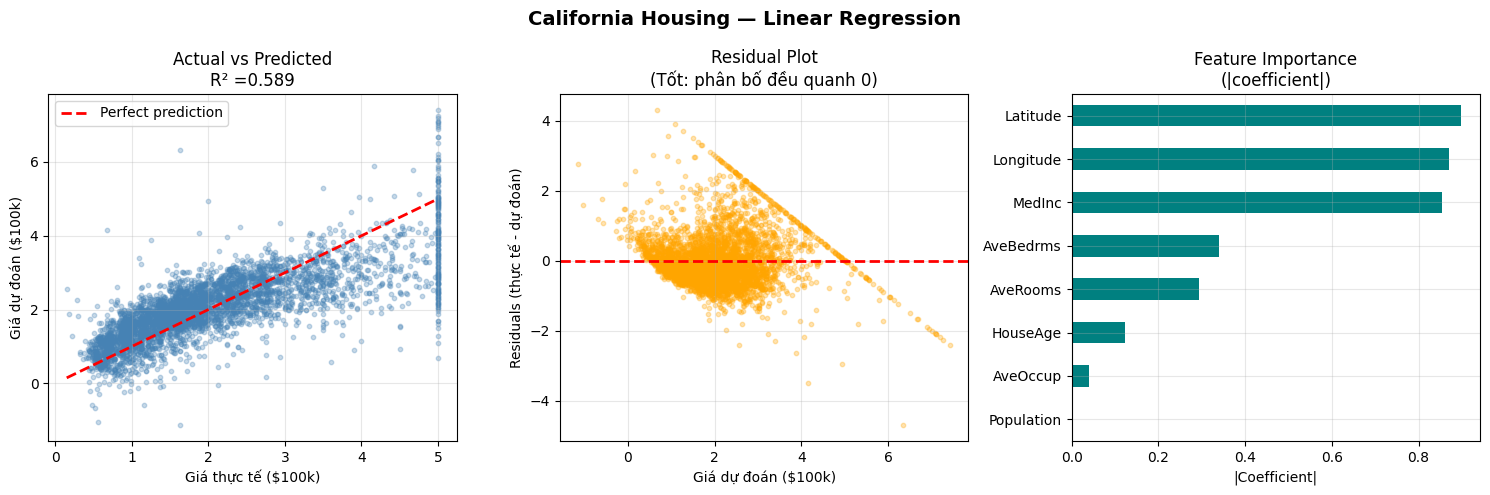


✅ Hoàn thành!


In [41]:
print("BƯỚC 6: VISUALIZE KẾT QUẢ")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Predicted vs Actual ---
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel("Giá thực tế ($100k)")
axes[0].set_ylabel("Giá dự đoán ($100k)")
axes[0].set_title(f"Actual vs Predicted\nR² ={r2_test:.3f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Residuals ---
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='orange')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel("Giá dự đoán ($100k)")
axes[1].set_ylabel("Residuals (thực tế - dự đoán)")
axes[1].set_title("Residual Plot\n(Tốt: phân bố đều quanh 0)")
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Feature Importance ---
feature_importance = pd.Series(np.abs(model.coef_), index=housing.feature_names)
feature_importance.sort_values().plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title("Feature Importance\n(|coefficient|)")
axes[2].set_xlabel("|Coefficient|")
axes[2].grid(True, alpha=0.3)

plt.suptitle("California Housing — Linear Regression", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("bai_tap_3_california_housing.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Hoàn thành!")